In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px


In [24]:
stocks = [
    "Reliance Industries", "Tata Consultancy Services", "HDFC Bank", "Infosys", "Hindustan Unilever",
    "ICICI Bank", "State Bank of India", "Bharti Airtel", "Kotak Mahindra Bank", "HDFC",
    "Bajaj Finance", "Larsen & Toubro", "ITC", "Axis Bank", "Asian Paints",
    "Maruti Suzuki", "Wipro", "UltraTech Cement", "Nestle India", "Sun Pharma"
]

# Sample news events with realistic impacts
news_samples = [
    ("expands its retail operations", "Business", 0.03, 0.07, 0.15),
    ("secures a major contract in Europe", "Business", 0.02, 0.05, 0.10),
    ("reports record profits for the quarter", "Finance", 0.04, 0.08, 0.18),
    ("faces legal challenges in the US", "Legal", -0.03, -0.06, -0.12),
    ("launches a new product line", "Business", 0.02, 0.04, 0.09),
    ("announces a strategic partnership", "Business", 0.03, 0.06, 0.13),
    ("reveals quarterly earnings beat expectations", "Finance", 0.05, 0.09, 0.20),
    ("faces increased market competition", "Market", -0.02, -0.04, -0.08),
    ("announces a significant dividend payout", "Finance", 0.01, 0.03, 0.07),
    ("introduces innovative technology", "Technology", 0.03, 0.07, 0.14),
    ("expands its digital lending platform", "Technology", 0.04, 0.08, 0.17),
    ("secures a major infrastructure project", "Business", 0.02, 0.05, 0.11),
    ("faces regulatory challenges", "Legal", -0.02, -0.05, -0.10),
    ("partners with fintech startup", "Business", 0.03, 0.06, 0.12),
    ("reports increased quarterly sales", "Finance", 0.02, 0.05, 0.10),
    ("launches new electric vehicle", "Technology", 0.04, 0.09, 0.18),
    ("announces layoffs amid restructuring", "Market", -0.03, -0.07, -0.14),
    ("reports higher production costs", "Finance", -0.02, -0.05, -0.11),
    ("introduces new health-conscious product line", "Business", 0.02, 0.04, 0.08),
    ("faces challenges with drug approval", "Legal", -0.04, -0.08, -0.16)
]

# Generate sample data
data = []
for i in range(1000):
    stock, category, impact_1h, impact_1d, impact_1w = news_samples[i % len(news_samples)]
    stock_name = stocks[i % len(stocks)]
    data.append({
        "Stock Name": stock_name,
        "1 Hour Relative Impact": impact_1h + np.random.uniform(-0.005, 0.005),
        "1 Day Impact": impact_1d + np.random.uniform(-0.01, 0.01),
        "1 Week Impact": impact_1w + np.random.uniform(-0.02, 0.02),
        "News Content": f"{stock_name} {category.lower()} news: {stock} {category}.",
        "News Category": category
    })

# Create DataFrame
df = pd.DataFrame(data)

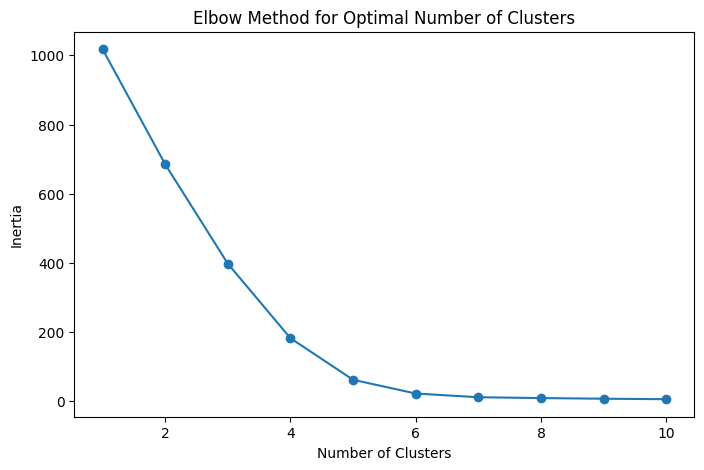

,Stock Name,1 Hour Relative Impact,1 Day Impact,1 Week Impact,News Content,News Category,Cluster
0,Reliance Industries,0.031017,0.067055,0.169723,Reliance Industries business news: expands its...,Business,1
1,Tata Consultancy Services,0.017499,0.059588,0.097806,Tata Consultancy Services business news: secur...,Business,1
2,HDFC Bank,0.039387,0.080707,0.187339,HDFC Bank finance news: reports record profits...,Finance,0
3,Infosys,-0.026728,-0.053787,-0.107461,Infosys legal news: faces legal challenges in ...,Legal,2
4,Hindustan Unilever,0.021701,0.035590,0.095733,Hindustan Unilever business news: launches a n...,Business,1


In [27]:
# Vectorize the news content
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
news_vectors = vectorizer.fit_transform(df['News Category'])

# Combine the vectorized news content with the impact data
impact_data = df[['1 Hour Relative Impact', '1 Day Impact', '1 Week Impact']].values
combined_data = pd.concat([pd.DataFrame(impact_data), pd.DataFrame(news_vectors.toarray())], axis=1)

# Normalize each column to give equal weight
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(combined_data)

# Determine the optimal number of clusters using the Elbow method
inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(normalized_data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

# Apply KMeans with the optimal number of clusters (e.g., 5)
optimal_clusters = 5  # Set based on the Elbow method result
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(normalized_data)


df.head()


In [28]:
news_vectors

<1000x5 sparse matrix of type '<class 'numpy.float64'>'
	with 1000 stored elements in Compressed Sparse Row format>

In [29]:


# Plot the clusters using Plotly
fig = px.scatter(
    df, x='1 Hour Relative Impact', y='1 Day Impact', color='Cluster', hover_data=['Stock Name', 'News Content'],
    title='Interactive Clustering of Stock News',
    labels={'PCA1': 'Principal Component 1', 'PCA2': 'Principal Component 2'}
)

# Show the plot
fig.show()